In [3]:
import numpy as np

from scipy.special import comb as n_choose_k
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr, spearmanr
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from itertools import combinations
from collections import defaultdict
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda')
device

from data import *

In [4]:
torch.cuda.is_available()

True

In [5]:
# Parameters
seed = 7012025
C = np.inf # no regularisation for lin. regression
power = 1 # uniform density
D = 1000 # number of data samples
N = 100 # number of sources
K = 10 # sparsity
num_ood = N // 2 # how many new OOD sources
M = int(np.ceil(K * np.log(N / K) * 1)) # Compressed Sensing bound
num_ood, M

(50, 24)

# Game Plan

### IID means either:

a) first index and any of the IID distractors [cow and grass]

b) NOT the first index and ANY of the distractors [grass and sand]

### OOD means:

c) first index and any of the OOD distractors [cow and sand]

In [6]:
# Full example: train encoder with matrix A...

In [7]:
# lazy example (might not be perfect), just draw random A
np.random.seed(seed)
# https://en.wikipedia.org/wiki/Restricted_isometry_property
A = np.random.normal(0, 1, (M, N)) # random normal has RIP -> CS works =)
A /= np.linalg.norm(A, axis=0, keepdims=True)
A.min(), A.max(), A.shape

(np.float64(-0.6458119825139067), np.float64(0.6527911931680838), (24, 100))

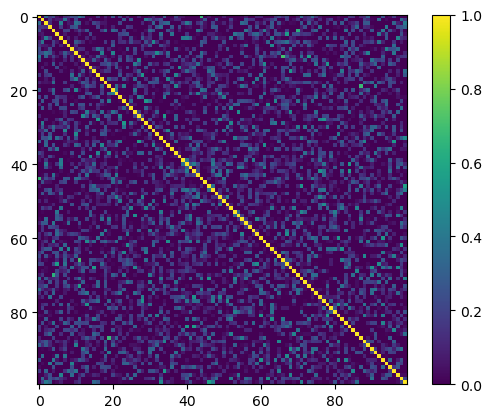

In [8]:
plt.imshow(A.T @ A, vmin=0, vmax=1, cmap='viridis')
plt.colorbar()

In [9]:
# generate data
np.random.seed(seed)

Z_iid = np.array([sample_iid(N=N, K=K) for _ in range(D)])
Y_iid = Z_iid @ A.T
label_iid = Z_iid[:, 0] > .5

Z_ood = np.array([sample_ood(N=N, K=K) for _ in range(D)])
Y_ood = Z_ood @ A.T
label_ood = Z_ood[:, 0] > .5

Z_iid.shape, Y_iid.shape, label_iid[:10], np.mean(label_iid)

((1000, 100),
 (1000, 24),
 array([False, False, False, False, False, False,  True, False, False,
        False]),
 np.float64(0.237))

In [10]:
Y_all = np.vstack([Y_iid, Y_ood])

In [11]:
Z_all = np.vstack([Z_iid, Z_ood])

In [10]:
# test linear probe
clf = LogisticRegression(C=C).fit(Z_iid, label_iid)

acc_iid = clf.score(Z_iid, label_iid)
acc_ood = clf.score(Z_ood, label_ood)
print(f'In source (Z) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

clf = LogisticRegression(C=C).fit(Y_iid, label_iid)

acc_iid = clf.score(Y_iid, label_iid)
acc_ood = clf.score(Y_ood, label_ood)
print(f'In observation (Y=AZ) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

In source (Z) space: acc IID: 1.000, acc OOD: 0.950
In observation (Y=AZ) space: acc IID: 0.889, acc OOD: 0.596


In [11]:
# SAE setting
# train SAE to go from Y back to estimated/reconstructed sources Z_
# On Z_, train linear classifier - how good?

# Sparse code (supervised) setting
Given matrix A, infer Z_

On Z_, train linear classifier - how good?

In [30]:
from sklearn.decomposition import DictionaryLearning
from sklearn.decomposition import sparse_encode

z_rec = sparse_encode(Y_all, A.T, algorithm='lasso_cd', alpha=0, positive=True)

/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(


In [13]:
z_iid_rec = z_rec[0:len(Z_iid)]

In [14]:
z_ood_rec = z_rec[len(Z_iid):]

In [15]:
clf = LogisticRegression(C=C).fit(z_iid_rec, label_iid)

acc_iid = clf.score(z_iid_rec, label_iid)
acc_ood = clf.score(z_ood_rec, label_ood)
print(f'acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

acc IID: 0.935, acc OOD: 0.547


Question: It is a bit weird to call the second half OOD if we're still training on it. But how else can we train the classifier on top of new features?

It's OOD only for the classifier but not for the sparse encoder. Ideally, we should train the encoder on the IID set and then apply the same dictionary to the OOD case, but it's not going to be sparse...

Or maybe for dictionary learning, OOD means that we reuse the dictionary but still train the z to be sparse?

In [16]:
z_in = sparse_encode(Y_iid, A.T, algorithm='lasso_cd', alpha=0, positive=True)

/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(


In [17]:
clf = LogisticRegression(C=C).fit(z_in, label_iid)

In [18]:
acc_iid = clf.score(z_in, label_iid)

In [19]:
acc_iid

0.935

In [22]:
z_ood = Y_ood @ A

In [23]:
def mean_corr_coef(
    z1: np.ndarray, z2: np.ndarray, method: str = 'pearson'
) -> float:
    """Calculate the mean correlation coefficient between two sets of vectors."""
    if method == 'pearson':
        return np.mean([pearsonr(z1[i], z2[i])[0] for i in range(len(z1))])
    elif method == 'spearman':
        return np.mean([spearmanr(z1[i], z2[i])[0] for i in range(len(z1))])
    else:
        raise ValueError("Method must be either 'pearson' or 'spearman'"
)

In [24]:
mean_corr_coef(z_in, Z_iid, method='pearson')

np.float64(0.5131218972158934)

In [25]:
acc_ood = clf.score(z_ood, label_ood)

In [26]:
acc_ood

0.551

# Sparse code (unsupervised) setting

learn both matrix A and Z_

On Z_, train linear classifier - how good?

In [30]:
num_seed = 1

# target = np.concatenate([z_01, z_12, z_02], 0)
# inputs = target @ A
# inputs = torch.tensor(inputs, dtype=torch.float32, device=device)
# target = torch.tensor(target, dtype=torch.float32, device=device)

inputs = torch.tensor(Y_all, dtype=torch.float32, device=device)

best_loss = np.inf
best_D, best_Z = None, None

d_x = inputs.shape[1]
d_z = Z_iid.shape[1]
n_points = inputs.shape[0]

for rep in range(num_seed):
    torch.manual_seed(seed + rep)

    log_Z = torch.randn(n_points, d_z, device=device).requires_grad_()
    D = torch.randn(d_z, d_x, device=device).requires_grad_()
    # D = torch.tensor(A, dtype=torch.float32, device=device)
    optim = torch.optim.Adam([log_Z, D], lr=1e-2)

    for i in tqdm(range(100000)):
        # Z = torch.exp(log_Z)
        Z = torch.nn.functional.softplus(log_Z)
        # Z = torch.nn.functional.relu(log_Z)
        # Z = torch.nn.functional.gelu(log_Z)
        rec = Z @ D
        # print(rec.shape)
        mse = torch.mean((inputs - rec)**2)
        # l1 = torch.mean(Z)
        l1 = torch.mean(torch.abs(Z) * torch.linalg.norm(D, dim=1))
        loss = mse + 0.001 * l1
        optim.zero_grad()
        loss.backward()
        optim.step()

        # D.data /= torch.linalg.norm(D, dim=1, keepdim=True)
        
        # if rep == 0 and not i % 10000:
        #     print(rep, i, mse.item(), l1.item())
        #     fig = plt.figure()
        #     ax = fig.add_subplot(projection='3d')
        #     ax.scatter(*Z.detach().cpu().numpy().T,)
        #     ax.view_init(elev=30, azim=45, roll=0)
        #     plt.show()

        if i > 10000:
            if loss.item() > best_loss * 1.1:
                break
    print(rep, i, mse.item(), l1.item())
    # fig = plt.figure()
    # ax = fig.add_subplot(projection='3d')
    # ax.scatter(*Z.detach().cpu().numpy().T, s=5)
    # ax.view_init(elev=30, azim=45, roll=0)
    # plt.show()
    if loss.item() < best_loss:
        best_D = D.detach().cpu().numpy()
        best_Z = Z.detach().cpu().numpy()

100%|██████████| 100000/100000 [00:51<00:00, 1944.96it/s]

0 99999 1.6299827620969154e-06 0.055065739899873734


In [33]:
best_Z.shape

(2000, 100)

In [34]:
Z_iid.shape

(1000, 100)

In [36]:
best_Z[0:1000].shape

(1000, 100)

In [37]:
mean_corr_coef(best_Z[0:1000], Z_iid, method='pearson')

np.float64(-0.007440333247986983)

In [38]:
z_iid_rec = best_Z[0:len(Z_iid)]

In [39]:
z_ood_rec = best_Z[len(Z_iid):]

In [40]:
clf = LogisticRegression(C=C).fit(z_iid_rec, label_iid)

acc_iid = clf.score(z_iid_rec, label_iid)
acc_ood = clf.score(z_ood_rec, label_ood)
print(f'acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

acc IID: 0.912, acc OOD: 0.576


In [1]:
## Train z on IID only

In [14]:
num_seed = 1

# target = np.concatenate([z_01, z_12, z_02], 0)
# inputs = target @ A
# inputs = torch.tensor(inputs, dtype=torch.float32, device=device)
# target = torch.tensor(target, dtype=torch.float32, device=device)

inputs = torch.tensor(Y_iid, dtype=torch.float32, device=device)

best_loss = np.inf
best_D, best_Z = None, None

d_x = inputs.shape[1]
d_z = Z_iid.shape[1]
n_points = inputs.shape[0]

losses = []

for rep in range(num_seed):
    torch.manual_seed(seed + rep)

    log_Z = torch.randn(n_points, d_z, device=device).requires_grad_()
    D = torch.randn(d_z, d_x, device=device).requires_grad_()
    # D = torch.tensor(A, dtype=torch.float32, device=device)
    optim = torch.optim.Adam([log_Z, D], lr=1e-2)

    for i in tqdm(range(100000)):
        # Z = torch.exp(log_Z)
        Z = torch.nn.functional.softplus(log_Z)
        # Z = torch.nn.functional.relu(log_Z)
        # Z = torch.nn.functional.gelu(log_Z)
        rec = Z @ D
        # print(rec.shape)
        mse = torch.mean((inputs - rec)**2)
        # l1 = torch.mean(Z)
        l1 = torch.mean(torch.abs(Z) * torch.linalg.norm(D, dim=1))
        loss = mse + 0.001 * l1
        optim.zero_grad()
        loss.backward()
        optim.step()

        losses.append(loss.item())

        # D.data /= torch.linalg.norm(D, dim=1, keepdim=True)
        
        # if rep == 0 and not i % 10000:
        #     print(rep, i, mse.item(), l1.item())
        #     fig = plt.figure()
        #     ax = fig.add_subplot(projection='3d')
        #     ax.scatter(*Z.detach().cpu().numpy().T,)
        #     ax.view_init(elev=30, azim=45, roll=0)
        #     plt.show()

        if i > 10000:
            if loss.item() > best_loss * 1.1:
                break
    print(rep, i, mse.item(), l1.item())
    # fig = plt.figure()
    # ax = fig.add_subplot(projection='3d')
    # ax.scatter(*Z.detach().cpu().numpy().T, s=5)
    # ax.view_init(elev=30, azim=45, roll=0)
    # plt.show()
    if loss.item() < best_loss:
        best_D = D.detach().cpu().numpy()
        best_Z = Z.detach().cpu().numpy()

100%|██████████| 100000/100000 [00:49<00:00, 2018.44it/s]

0 99999 5.735117838412407e-07 0.05217593535780907


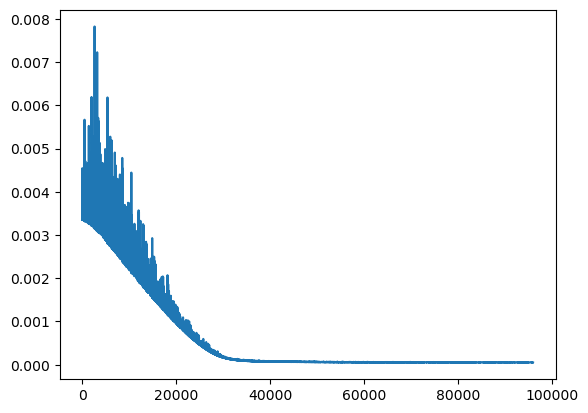

In [17]:
plt.plot(losses[4000:])

In [31]:
Z_hat_ood = sparse_encode(Y_ood, best_D, algorithm='lasso_cd', alpha=0, positive=True)

/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(


In [34]:
clf = LogisticRegression(C=C).fit(best_Z, label_iid)

acc_iid = clf.score(best_Z, label_iid)
acc_ood = clf.score(Z_hat_ood, label_ood)
print(f'acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

acc IID: 0.919, acc OOD: 0.482


In [ ]:
## Does it make sense to train the downstream classifier on IID only? Or should I include OOD data as well?

In [35]:
all_Z = np.concatenate([best_Z, Z_hat_ood], 0)

In [38]:
all_labels = np.concatenate([label_iid, label_ood], 0)

In [39]:
all_labels.shape

(2000,)

In [41]:
clf = LogisticRegression(C=C).fit(all_Z, all_labels)

acc_iid = clf.score(best_Z, label_iid)
acc_ood = clf.score(Z_hat_ood, label_ood)
print(f'acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

acc IID: 0.890, acc OOD: 0.839


## Create validation set for hyperparameter selection

In [ ]:
# Parameters
seed = 7012025
C = np.inf # no regularisation for lin. regression
power = 1 # uniform density
D = 2000 # number of data samples
N = 100 # number of sources
K = 10 # sparsity
num_ood = N // 2 # how many new OOD sources
M = int(np.ceil(K * np.log(N / K) * 1)) # Compressed Sensing bound
num_ood, M